In [1]:
from single_qubit_rcs import SingleQubitRCS

In [ ]:
rcs = SingleQubitRCS(mode='clifford', seed=42)
rcs.verify_all()                          # ensure clifford single qubit operations are implemented correctly
results = rcs.sweep([10, 50, 100, 200])   # single layer of clifford single qubit gate RCS

gate     init    p0_mbqc  p0_direct      TVD
---------------------------------------------
√X       |0>       0.526      0.509   0.0171
√X       |1>       0.481      0.503   0.0220
√X       |+>       0.487      0.494   0.0073
√Y       |0>       0.483      0.507   0.0244
√Y       |1>       0.501      0.494   0.0078
√Y       |+>       0.000      0.000   0.0000
---------------------------------------------
Max TVD: 0.0244  (expected ~0 within shot noise)
    N  depth   qubits      t_MBQC    t_direct   mean TVD   max TVD
----------------------------------------------------------------------
   10      1       20     0.763s     0.757s     0.0275    0.0605
   50      1      100     0.899s     0.817s     0.0202    0.0605
  100      1      200     1.474s     0.855s     0.0219    0.0898
  200      1      400     3.034s     1.514s     0.0233    0.1094


In [3]:
rcs.sweep([10, 50, 100], depth=5)

    N  depth   qubits      t_MBQC    t_direct   mean TVD   max TVD
----------------------------------------------------------------------
   10      5       20     0.719s     0.898s     0.0193    0.0566
   50      5      100     1.771s     0.820s     0.0170    0.0840
  100      5      200     4.229s     0.963s     0.0201    0.0781


[{'n': 10,
  'depth': 5,
  'qubits_mbqc': 20,
  't_mbqc': 0.7193887233734131,
  't_direct': 0.8979454040527344,
  'speedup': 0.8011497359712139,
  'tvd_mean': 0.0193359375,
  'tvd_max': 0.056640625,
  'gates': [['sqrt_Y',
    'sqrt_Y',
    'sqrt_X',
    'sqrt_Y',
    'sqrt_X',
    'sqrt_Y',
    'sqrt_X',
    'sqrt_X',
    'sqrt_X',
    'sqrt_Y'],
   ['sqrt_X',
    'sqrt_Y',
    'sqrt_X',
    'sqrt_X',
    'sqrt_Y',
    'sqrt_X',
    'sqrt_Y',
    'sqrt_Y',
    'sqrt_X',
    'sqrt_X'],
   ['sqrt_X',
    'sqrt_Y',
    'sqrt_Y',
    'sqrt_X',
    'sqrt_X',
    'sqrt_X',
    'sqrt_X',
    'sqrt_Y',
    'sqrt_Y',
    'sqrt_X'],
   ['sqrt_Y',
    'sqrt_X',
    'sqrt_X',
    'sqrt_Y',
    'sqrt_Y',
    'sqrt_Y',
    'sqrt_X',
    'sqrt_X',
    'sqrt_X',
    'sqrt_X'],
   ['sqrt_Y',
    'sqrt_Y',
    'sqrt_X',
    'sqrt_Y',
    'sqrt_X',
    'sqrt_Y',
    'sqrt_X',
    'sqrt_X',
    'sqrt_Y',
    'sqrt_X']]},
 {'n': 50,
  'depth': 5,
  'qubits_mbqc': 100,
  't_mbqc': 1.7706599235534668,
  't_d

In [ ]:
# Non-Clifford mode → statevector
rcs_nc = SingleQubitRCS(mode='supremacy', seed=42)
rcs_nc.verify_all()
rcs_nc.sweep([2, 4, 8])

gate     init    p0_mbqc  p0_direct      TVD
---------------------------------------------
√X       |0>       0.525      0.500   0.0249
√X       |1>       0.502      0.528   0.0264
√X       |+>       0.484      0.487   0.0034
√Y       |0>       0.495      0.499   0.0039
√Y       |1>       0.516      0.497   0.0195
√Y       |+>       0.000      0.000   0.0000
√W       |0>       0.502      0.497   0.0049
√W       |1>       0.501      0.506   0.0044
√W       |+>       0.144      0.150   0.0063
---------------------------------------------
Max TVD: 0.0264  (expected ~0 within shot noise)
    N  depth   qubits      t_MBQC    t_direct   mean TVD   max TVD
----------------------------------------------------------------------
    2      1        4     0.249s     0.345s     0.0361    0.0488
    4      1        8     0.489s     0.322s     0.0312    0.0566
    8      1       16    18.494s     0.178s     0.0305    0.0469


[{'n': 2,
  'depth': 1,
  'qubits_mbqc': 4,
  't_mbqc': 0.2494974136352539,
  't_direct': 0.34510040283203125,
  'speedup': 0.7229705082572458,
  'tvd_mean': 0.0361328125,
  'tvd_max': 0.048828125,
  'gates': [['sqrt_X', 'sqrt_W']]},
 {'n': 4,
  'depth': 1,
  'qubits_mbqc': 8,
  't_mbqc': 0.489330530166626,
  't_direct': 0.3221292495727539,
  'speedup': 1.519050290576327,
  'tvd_mean': 0.03125,
  'tvd_max': 0.056640625,
  'gates': [['sqrt_Y', 'sqrt_Y', 'sqrt_Y', 'sqrt_W']]},
 {'n': 8,
  'depth': 1,
  'qubits_mbqc': 16,
  't_mbqc': 18.49364709854126,
  't_direct': 0.17775535583496094,
  'speedup': 104.03988679650196,
  'tvd_mean': 0.030517578125,
  'tvd_max': 0.046875,
  'gates': [['sqrt_X',
    'sqrt_W',
    'sqrt_X',
    'sqrt_X',
    'sqrt_Y',
    'sqrt_W',
    'sqrt_W',
    'sqrt_W']]}]

In [6]:
# increase depth for 8 pairs (8 qubits)
for d in [1, 2, 5, 10, 20]:
    r = rcs_nc.run_rcs(n_pairs=8, depth=d)
    print(f"depth={d:3d}  t_mbqc={r['t_mbqc']:.3f}s  t_direct={r['t_direct']:.3f}s  tvd={r['tvd_mean']:.4f}")

depth=  1  t_mbqc=21.359s  t_direct=0.249s  tvd=0.0242
depth=  2  t_mbqc=37.334s  t_direct=0.267s  tvd=0.0215
depth=  5  t_mbqc=90.207s  t_direct=0.216s  tvd=0.0217
depth= 10  t_mbqc=170.259s  t_direct=0.158s  tvd=0.0195
depth= 20  t_mbqc=373.986s  t_direct=0.145s  tvd=0.0122


    N  depth   qubits      t_MBQC    t_direct   mean TVD   max TVD
----------------------------------------------------------------------
   50      1      100     1.085s     1.275s     0.0262    0.0996
  100      1      200     1.894s     1.055s     0.0265    0.0957
  150      1      300     2.178s     1.086s     0.0233    0.0879
  200      1      400     2.991s     1.116s     0.0268    0.0918
  250      1      500     4.809s     1.247s     0.0257    0.0898
  300      1      600     6.537s     1.340s     0.0259    0.0977
  350      1      700     8.870s     1.858s     0.0237    0.0762
  400      1      800    10.182s     2.132s     0.0243    0.0879
  450      1      900    14.927s     1.716s     0.0249    0.0957
  500      1     1000    16.973s     2.208s     0.0262    0.0898


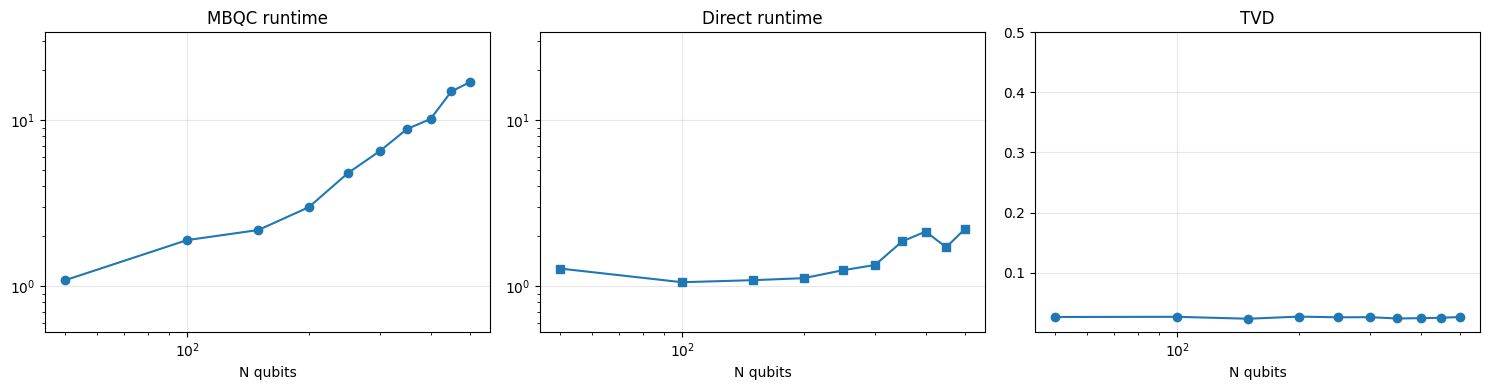

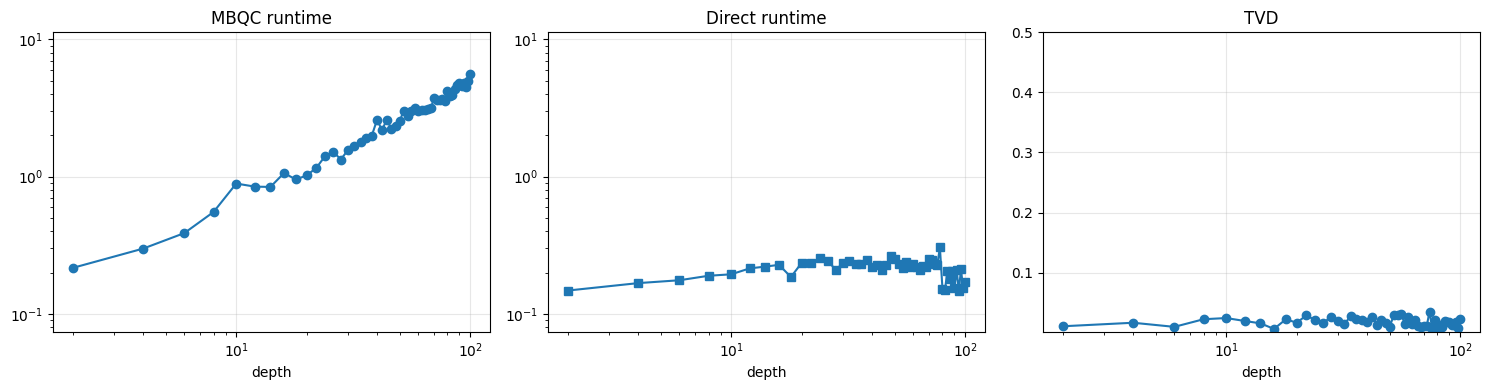

In [ ]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

qubit_sweep = list(range(50,501,50))
depth_sweep = list(range(2,102,2))

#sweep number of qubits (depth 1)
rcs = SingleQubitRCS(mode='clifford', seed=42)
results_q = rcs.sweep(qubit_sweep, depth=1)
pickle.dump(results_q, open('sweep_qubits.pkl', 'wb'))


#sweep depth (4 qubits)
rcs = SingleQubitRCS(mode='supremacy', seed=42)
results_d = [rcs.run_rcs(n_pairs=4, depth=d) for d in depth_sweep]
print(f"depth={d:3d}  t_mbqc={results_d['t_mbqc']:.3f}s  t_direct={results_d['t_direct']:.3f}s  tvd={results_d['tvd_mean']:.4f}")
pickle.dump(results_d, open('sweep_depth.pkl', 'wb'))

#plotting
def plot(results, x_key, x_label):
    xs = [r[x_key] for r in results]
    t_mbqc   = [r['t_mbqc']   for r in results]
    t_direct = [r['t_direct'] for r in results]
 
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].loglog(xs, t_mbqc,   'o-'); axes[0].set_title('MBQC runtime')
    axes[1].loglog(xs, t_direct, 's-'); axes[1].set_title('Direct runtime')
    axes[2].semilogx(xs, [r['tvd_mean'] for r in results], 'o-'); axes[2].set_title('TVD')
    axes[2].set_ylim(0.001, 0.5)
 
    y_lo = min(min(t_mbqc), min(t_direct)) * 0.5
    y_hi = max(max(t_mbqc), max(t_direct)) * 2
    axes[0].set_ylim(y_lo, y_hi)
    axes[1].set_ylim(y_lo, y_hi)
 
    for ax in axes:
        ax.set_xlabel(x_label); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
 
plot(pickle.load(open('sweep_qubits.pkl', 'rb')), 'n',     'N qubits')
plot(pickle.load(open('sweep_depth.pkl',  'rb')), 'depth', 'depth')